# CarWorth — Model Training (XGBoost)
**Input:** `data/processed/vehicles_clean.csv`  
**Output:** `models/xgb_model.joblib`, `models/feature_names.json`, `models/encoders.joblib`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Load Clean Data

In [2]:
df = pd.read_csv('../data/processed/vehicles_clean.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (368075, 20)


,price,log_price,year,car_age,odometer,log_odometer,miles_per_year,manufacturer,fuel,transmission,drive,type,condition,condition_num,cylinders,state,paint_color,is_luxury,is_clean_title,is_automatic
0,33590,10.422013,2014.0,10,57923.0,10.966887,5792.300000,gmc,gas,other,unknown,pickup,good,2,8 cylinders,al,white,0,1,0
1,22590,10.025307,2010.0,14,71229.0,11.173669,5087.785714,chevrolet,gas,other,unknown,pickup,good,2,8 cylinders,al,blue,0,1,0
2,39590,10.586357,2020.0,4,19160.0,9.860632,4790.000000,chevrolet,gas,other,unknown,pickup,good,2,8 cylinders,al,red,0,1,0


## 2. Define Features & Target

In [3]:
FEATURES = [
    'year', 'car_age', 'log_odometer', 'miles_per_year', 'condition_num',
    'manufacturer', 'fuel', 'transmission', 'drive', 'type',
    'cylinders', 'state',
    'is_luxury', 'is_clean_title', 'is_automatic'
]

TARGET = 'log_price'

FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Features ({len(FEATURES)}): {FEATURES}')

Features (15): ['year', 'car_age', 'log_odometer', 'miles_per_year', 'condition_num', 'manufacturer', 'fuel', 'transmission', 'drive', 'type', 'cylinders', 'state', 'is_luxury', 'is_clean_title', 'is_automatic']


## 3. Encode Categorical Features

In [4]:
CAT_COLS = ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'cylinders', 'state']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print('Label encoding applied to:', CAT_COLS)

Label encoding applied to: ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'cylinders', 'state']


## 4. Train/Test Split

In [5]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (294460, 15), Test: (73615, 15)


## 5. Baseline XGBoost Model

In [6]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.87371
[100]	validation_0-rmse:0.48388
[200]	validation_0-rmse:0.46302
[300]	validation_0-rmse:0.45141
[400]	validation_0-rmse:0.44301
[499]	validation_0-rmse:0.43612


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## 6. Evaluation

In [7]:
y_pred_log = model.predict(X_test)

# Back to original price scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MAE  : ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

MAE  : $3,898
RMSE : $6,954
R²   : 0.7745
MAPE : 43.55%


## 7. Predicted vs Actual

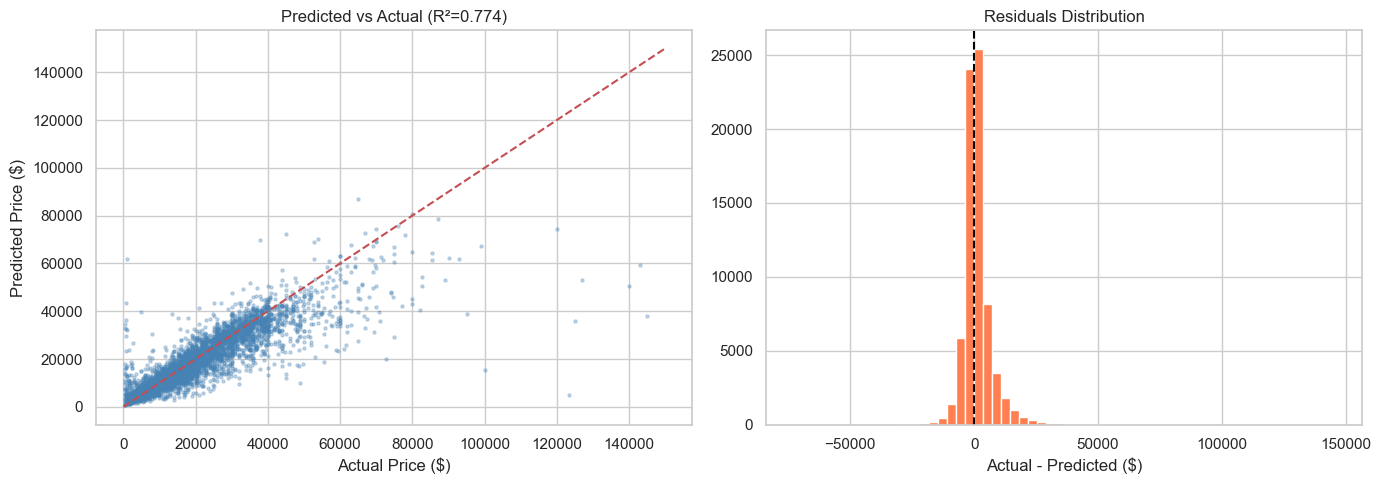

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
sample = min(5000, len(y_true))
idx = np.random.choice(len(y_true), sample, replace=False)
axes[0].scatter(y_true.iloc[idx], y_pred[idx], alpha=0.3, s=5, color='steelblue')
lim = max(y_true.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Predicted vs Actual (R²={r2:.3f})')

# Residuals
residuals = y_true.values - y_pred
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Actual - Predicted ($)')

plt.tight_layout()
plt.savefig('../assets/03_model/model_evaluation.png', dpi=150)
plt.show()

## 8. Feature Importance

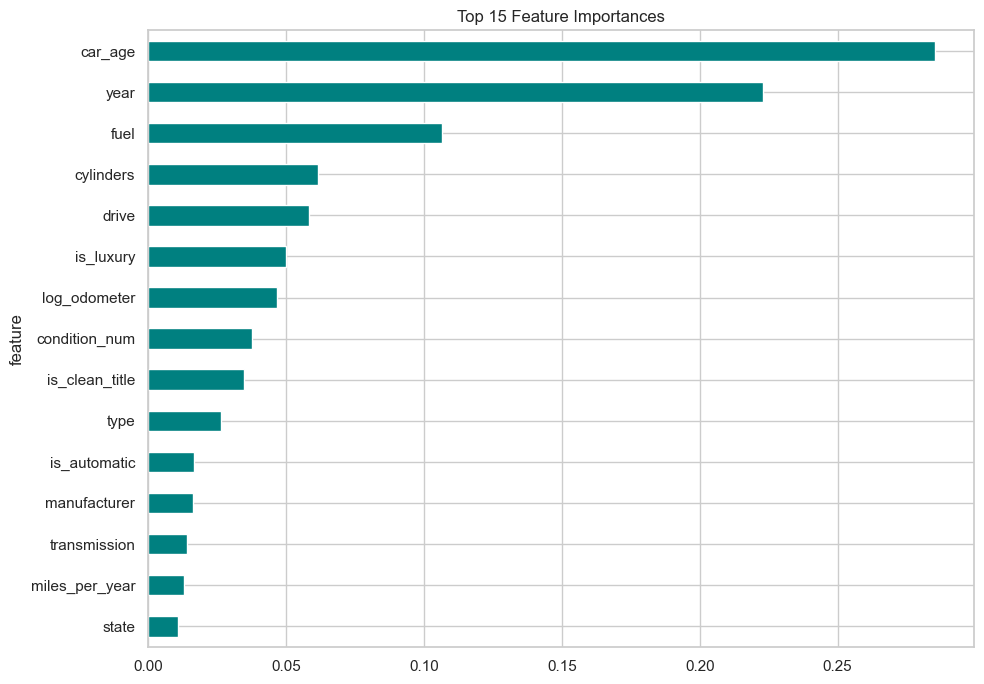

,feature,importance
1,car_age,0.285208
0,year,0.222767
6,fuel,0.106643
10,cylinders,0.061529
8,drive,0.058398
12,is_luxury,0.049766
2,log_odometer,0.046718
4,condition_num,0.037697
13,is_clean_title,0.034536
9,type,0.026395


In [9]:
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importance_df.head(15).plot(kind='barh', x='feature', y='importance', ax=ax, color='teal', legend=False)
ax.set_title('Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/03_model/feature_importance.png', dpi=150)
plt.show()

importance_df

## 9. Cross-Validation

In [10]:
cv_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f'CV R² scores: {cv_scores}')
print(f'Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV R² scores: [0.74816489 0.75049535 0.751348   0.75981107 0.74902427]
Mean R²: 0.7518 ± 0.0042


## 10. Save Model & Artifacts

In [11]:
joblib.dump(model, '../models/xgb_model.joblib')
joblib.dump(encoders, '../models/encoders.joblib')

with open('../models/feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

metrics = {'mae': float(mae), 'rmse': float(rmse), 'r2': float(r2), 'mape': float(mape)}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: xgb_model.joblib, encoders.joblib, feature_names.json, metrics.json')

Saved: xgb_model.joblib, encoders.joblib, feature_names.json, metrics.json
